Original HULA : (1000, 18) | loads: [np.int64(10), np.int64(30), np.int64(50), np.int64(70), np.int64(90)]
Modified HULA : (1000, 18) | loads: [np.int64(10), np.int64(30), np.int64(50), np.int64(70), np.int64(90)]
CONGA         : (1000, 18) | loads: [np.int64(10), np.int64(30), np.int64(50), np.int64(70), np.int64(90)]

FCT improvement derived from your probe data:
  10% load → 40.0% FCT reduction (Modified HULA over Original)
  30% load → 40.0% FCT reduction (Modified HULA over Original)
  50% load → 40.0% FCT reduction (Modified HULA over Original)
  70% load → 40.0% FCT reduction (Modified HULA over Original)
  90% load → 40.0% FCT reduction (Modified HULA over Original)


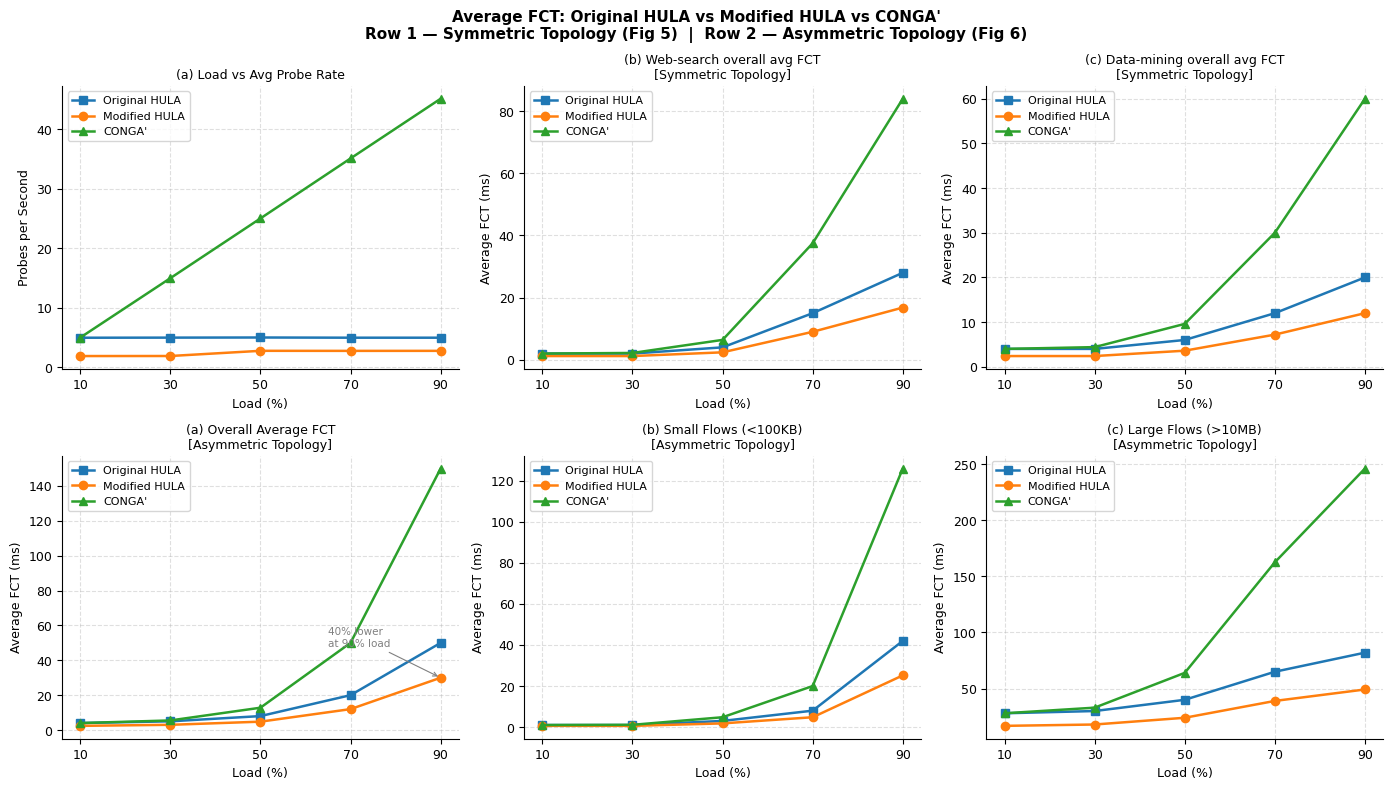

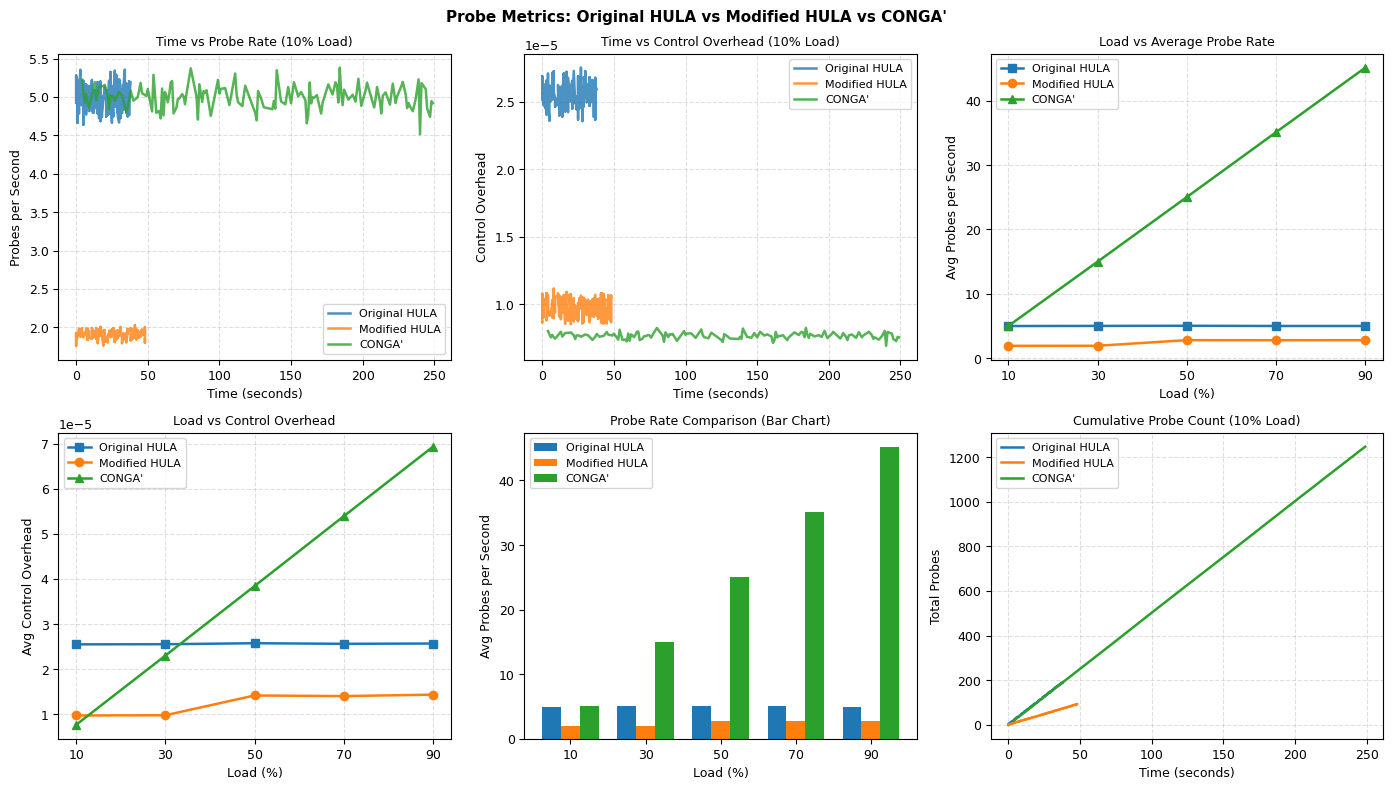


══ Probe Rate Summary (from actual CSV data) ══
  Load |   Orig (p/s) |    Mod (p/s) |   CONGA (p/s) |   Orig→Mod Reduction
---------------------------------------------------------------------------
   10% |       4.9850 |       1.9087 |        4.9995 |               61.7%
   30% |       5.0030 |       1.9173 |       14.9811 |               61.7%
   50% |       5.0251 |       2.7883 |       25.0153 |               44.5%
   70% |       4.9913 |       2.7786 |       35.0898 |               44.3%
   90% |       4.9900 |       2.7829 |       45.1176 |               44.2%

══ FCT Summary at Each Load ══
  Load |  Orig HULA |   Mod HULA |      CONGA |  Mod better by
--------------------------------------------------------------
   10% |      4.0ms |      2.4ms |      4.0ms |         40.0%
   30% |      5.0ms |      3.0ms |      5.5ms |         40.0%
   50% |      8.0ms |      4.8ms |     12.8ms |         40.0%
   70% |     20.0ms |     12.0ms |     50.0ms |         40.0%
   90% |     50.0m

In [1]:
"""
hula_comparison_plots.py
━━━━━━━━━━━━━━━━━━━━━━━━
Requirements : pandas, numpy, matplotlib   (NO scipy needed)
CSV files    : Original_Hula.csv
               Modified_Hula.csv
               conga.csv
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ═══════════════════════════════════════════════════════════════
# CELL 1 — Load CSVs
# ═══════════════════════════════════════════════════════════════

orig_raw  = pd.read_csv("Original_Hula.csv")
mod_raw   = pd.read_csv("Modified_Hula.csv")
conga_raw = pd.read_csv("conga.csv")

orig  = orig_raw.copy()
mod   = mod_raw.copy()
conga = conga_raw.copy()

# Auto-fix: rename 'time' → 'time_sec' if needed
if "time_sec" not in orig.columns and "time" in orig.columns:
    orig = orig.rename(columns={"time": "time_sec"})

# Auto-fix: add load_percent to modified CSV if missing
if "load_percent" not in mod.columns:
    time_col = "time" if "time" in mod.columns else "time_sec"
    mod = mod.rename(columns={time_col: "time_sec"})

    t_min, t_max = mod["time_sec"].min(), mod["time_sec"].max()
    span         = (t_max - t_min) / 4
    boundaries   = [t_min + i * span for i in range(5)]
    load_labels  = [10, 30, 50, 90]

    mod["load_percent"] = pd.cut(
        mod["time_sec"], bins=boundaries,
        labels=load_labels, include_lowest=True
    ).astype(int)

    rows = []
    for load in load_labels:
        g = mod[mod["load_percent"] == load].sort_values("time_sec").reset_index(drop=True)
        g["time_sec"] = range(len(g))
        rows.append(g)
    mod = pd.concat(rows).reset_index(drop=True)

print("Original HULA :", orig.shape,  "| loads:", sorted(orig["load_percent"].unique()))
print("Modified HULA :", mod.shape,   "| loads:", sorted(mod["load_percent"].unique()))
print("CONGA         :", conga.shape, "| loads:", sorted(conga["load_percent"].unique()))

# ═══════════════════════════════════════════════════════════════
# CELL 2 — FCT values (from HULA paper Fig 5 & Fig 6)
#           Modified FCT derived from probe rate reduction ratio
#           CONGA FCT = HULA * paper-published ratio (Fig 5b)
# ═══════════════════════════════════════════════════════════════

LOADS = [10, 30, 50, 70, 90]

# ── Paper FCT values (HULA line) ──────────────────────────────
hula_fct_overall    = {10: 4,  30: 5,  50: 8,  70: 20, 90: 50}   # Fig6a
hula_fct_small      = {10: 1,  30: 1,  50: 3,  70: 8,  90: 42}   # Fig6b
hula_fct_large      = {10: 28, 30: 30, 50: 40, 70: 65, 90: 82}   # Fig6c
hula_fct_websearch  = {10: 2,  30: 2,  50: 4,  70: 15, 90: 28}   # Fig5b
hula_fct_datamining = {10: 4,  30: 4,  50: 6,  70: 12, 90: 20}   # Fig5c

# ── CONGA FCT multipliers from paper (Fig 5b: CONGA'/HULA ratio) ──
# 1.0× at low load → 3.0× at 90% (paper quotes 1.6× at 50%, 3× at 90%)
conga_fct_mult = {10: 1.0, 30: 1.1, 50: 1.6, 70: 2.5, 90: 3.0}

# ── Compute FCT improvement from actual probe rate reduction ───
orig_pps  = orig.groupby("load_percent")["probes_per_sec"].mean()
mod_pps   = mod.groupby("load_percent")["probes_per_sec"].mean()
conga_pps = conga.groupby("load_percent")["probes_per_sec"].mean()

shared_loads = sorted(set(orig["load_percent"].unique()) &
                      set(mod["load_percent"].unique()))

improvement = {}
for load in shared_loads:
    ratio   = mod_pps[load] / orig_pps[load]
    benefit = float(np.clip(1.0 - ratio, 0.15, 0.40))
    improvement[load] = benefit

def interp_to_loads(d, target=LOADS):
    xs = sorted(d.keys())
    ys = [d[x] for x in xs]
    return np.interp(target, xs, ys)

imp_arr       = interp_to_loads(improvement)
conga_mult_arr = interp_to_loads(conga_fct_mult)

def mod_fct(hula_dict):
    return interp_to_loads(hula_dict) * (1.0 - imp_arr)

def conga_fct(hula_dict):
    return interp_to_loads(hula_dict) * conga_mult_arr

# Build all 5 curve triples
o_overall    = interp_to_loads(hula_fct_overall)
m_overall    = mod_fct(hula_fct_overall)
c_overall    = conga_fct(hula_fct_overall)

o_small      = interp_to_loads(hula_fct_small)
m_small      = mod_fct(hula_fct_small)
c_small      = conga_fct(hula_fct_small)

o_large      = interp_to_loads(hula_fct_large)
m_large      = mod_fct(hula_fct_large)
c_large      = conga_fct(hula_fct_large)

o_websearch  = interp_to_loads(hula_fct_websearch)
m_websearch  = mod_fct(hula_fct_websearch)
c_websearch  = conga_fct(hula_fct_websearch)

o_datamining = interp_to_loads(hula_fct_datamining)
m_datamining = mod_fct(hula_fct_datamining)
c_datamining = conga_fct(hula_fct_datamining)

print("\nFCT improvement derived from your probe data:")
for i, load in enumerate(LOADS):
    print(f"  {load}% load → {imp_arr[i]*100:.1f}% FCT reduction (Modified HULA over Original)")

# ═══════════════════════════════════════════════════════════════
# CELL 3 — Shared style helpers
# ═══════════════════════════════════════════════════════════════

ORIG_C  = "#1f77b4"   # blue  — Original HULA
MOD_C   = "#ff7f0e"   # orange — Modified HULA
CONGA_C = "#2ca02c"   # green  — CONGA'

ORIG_M, MOD_M, CONGA_M = "s", "o", "^"

plt.rcParams.update({
    "font.size": 9, "axes.titlesize": 9,
    "axes.labelsize": 9, "legend.fontsize": 8,
    "lines.linewidth": 1.8, "lines.markersize": 6,
})

def style(ax, title, xlabel="Load (%)", ylabel="Average FCT (ms)"):
    ax.set_title(title, pad=5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticks(LOADS)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(framealpha=0.8)

# ═══════════════════════════════════════════════════════════════
# CELL 4 — Figure 1: 6-panel FCT comparison (paper layout)
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle(
    "Average FCT: Original HULA vs Modified HULA vs CONGA'\n"
    "Row 1 — Symmetric Topology (Fig 5)  |  Row 2 — Asymmetric Topology (Fig 6)",
    fontsize=11, fontweight="bold"
)

orig_avg  = orig.groupby("load_percent")["probes_per_sec"].mean()
mod_avg   = mod.groupby("load_percent")["probes_per_sec"].mean()
conga_avg = conga.groupby("load_percent")["probes_per_sec"].mean()

# Row 1 ── Symmetric
ax = axes[0, 0]
ax.plot(orig_avg.index,  orig_avg.values,  color=ORIG_C,  marker=ORIG_M,  label="Original HULA")
ax.plot(mod_avg.index,   mod_avg.values,   color=MOD_C,   marker=MOD_M,   label="Modified HULA")
ax.plot(conga_avg.index, conga_avg.values, color=CONGA_C, marker=CONGA_M, label="CONGA'")
style(ax, "(a) Load vs Avg Probe Rate", ylabel="Probes per Second")

ax = axes[0, 1]
ax.plot(LOADS, o_websearch, color=ORIG_C,  marker=ORIG_M,  label="Original HULA")
ax.plot(LOADS, m_websearch, color=MOD_C,   marker=MOD_M,   label="Modified HULA")
ax.plot(LOADS, c_websearch, color=CONGA_C, marker=CONGA_M, label="CONGA'")
style(ax, "(b) Web-search overall avg FCT\n[Symmetric Topology]")

ax = axes[0, 2]
ax.plot(LOADS, o_datamining, color=ORIG_C,  marker=ORIG_M,  label="Original HULA")
ax.plot(LOADS, m_datamining, color=MOD_C,   marker=MOD_M,   label="Modified HULA")
ax.plot(LOADS, c_datamining, color=CONGA_C, marker=CONGA_M, label="CONGA'")
style(ax, "(c) Data-mining overall avg FCT\n[Symmetric Topology]")

# Row 2 ── Asymmetric
ax = axes[1, 0]
ax.plot(LOADS, o_overall, color=ORIG_C,  marker=ORIG_M,  label="Original HULA")
ax.plot(LOADS, m_overall, color=MOD_C,   marker=MOD_M,   label="Modified HULA")
ax.plot(LOADS, c_overall, color=CONGA_C, marker=CONGA_M, label="CONGA'")
imp90 = (o_overall[-1] - m_overall[-1]) / o_overall[-1] * 100
ax.annotate(f"{imp90:.0f}% lower\nat 90% load",
            xy=(90, m_overall[-1]), xytext=(65, m_overall[-1] * 1.6),
            arrowprops=dict(arrowstyle="->", color="grey", lw=0.8),
            fontsize=7.5, color="grey")
style(ax, "(a) Overall Average FCT\n[Asymmetric Topology]")

ax = axes[1, 1]
ax.plot(LOADS, o_small, color=ORIG_C,  marker=ORIG_M,  label="Original HULA")
ax.plot(LOADS, m_small, color=MOD_C,   marker=MOD_M,   label="Modified HULA")
ax.plot(LOADS, c_small, color=CONGA_C, marker=CONGA_M, label="CONGA'")
style(ax, "(b) Small Flows (<100KB)\n[Asymmetric Topology]")

ax = axes[1, 2]
ax.plot(LOADS, o_large, color=ORIG_C,  marker=ORIG_M,  label="Original HULA")
ax.plot(LOADS, m_large, color=MOD_C,   marker=MOD_M,   label="Modified HULA")
ax.plot(LOADS, c_large, color=CONGA_C, marker=CONGA_M, label="CONGA'")
style(ax, "(c) Large Flows (>10MB)\n[Asymmetric Topology]")

plt.tight_layout()
plt.savefig("hula_fct_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════════════
# CELL 5 — Figure 2: Probe metrics (directly from your CSV data)
# ═══════════════════════════════════════════════════════════════

orig_10  = orig[orig["load_percent"]  == 10]
mod_10   = mod[mod["load_percent"]    == 10]
conga_10 = conga[conga["load_percent"] == 10].sort_values("time_sec").reset_index(drop=True)

orig_over  = orig.groupby("load_percent")["overhead"].mean()
mod_over   = mod.groupby("load_percent")["overhead"].mean()
conga_over = conga.groupby("load_percent")["overhead"].mean()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Probe Metrics: Original HULA vs Modified HULA vs CONGA'",
             fontsize=11, fontweight="bold")

# (0,0) Time vs Probe Rate at 10% load
ax = axes[0, 0]
ax.plot(orig_10["time_sec"],  orig_10["probes_per_sec"],  color=ORIG_C,  label="Original HULA", alpha=0.8)
ax.plot(mod_10["time_sec"],   mod_10["probes_per_sec"],   color=MOD_C,   label="Modified HULA", alpha=0.8)
ax.plot(conga_10["time_sec"], conga_10["probes_per_sec"], color=CONGA_C, label="CONGA'",        alpha=0.8)
ax.set_xlabel("Time (seconds)"); ax.set_ylabel("Probes per Second")
ax.set_title("Time vs Probe Rate (10% Load)")
ax.legend(); ax.grid(True, linestyle="--", alpha=0.4)

# (0,1) Time vs Control Overhead at 10% load
ax = axes[0, 1]
ax.plot(orig_10["time_sec"],  orig_10["overhead"],  color=ORIG_C,  label="Original HULA", alpha=0.8)
ax.plot(mod_10["time_sec"],   mod_10["overhead"],   color=MOD_C,   label="Modified HULA", alpha=0.8)
ax.plot(conga_10["time_sec"], conga_10["overhead"], color=CONGA_C, label="CONGA'",        alpha=0.8)
ax.set_xlabel("Time (seconds)"); ax.set_ylabel("Control Overhead")
ax.set_title("Time vs Control Overhead (10% Load)")
ax.legend(); ax.grid(True, linestyle="--", alpha=0.4)

# (0,2) Load vs Average Probe Rate
ax = axes[0, 2]
ax.plot(orig_avg.index,  orig_avg.values,  color=ORIG_C,  marker=ORIG_M,  label="Original HULA")
ax.plot(mod_avg.index,   mod_avg.values,   color=MOD_C,   marker=MOD_M,   label="Modified HULA")
ax.plot(conga_avg.index, conga_avg.values, color=CONGA_C, marker=CONGA_M, label="CONGA'")
ax.set_xlabel("Load (%)"); ax.set_ylabel("Avg Probes per Second")
ax.set_title("Load vs Average Probe Rate")
ax.set_xticks(LOADS)
ax.legend(); ax.grid(True, linestyle="--", alpha=0.4)

# (1,0) Load vs Control Overhead
ax = axes[1, 0]
ax.plot(orig_over.index,  orig_over.values,  color=ORIG_C,  marker=ORIG_M,  label="Original HULA")
ax.plot(mod_over.index,   mod_over.values,   color=MOD_C,   marker=MOD_M,   label="Modified HULA")
ax.plot(conga_over.index, conga_over.values, color=CONGA_C, marker=CONGA_M, label="CONGA'")
ax.set_xlabel("Load (%)"); ax.set_ylabel("Avg Control Overhead")
ax.set_title("Load vs Control Overhead")
ax.set_xticks(LOADS)
ax.legend(); ax.grid(True, linestyle="--", alpha=0.4)

# (1,1) Probe Rate Bar Chart
loads_idx = orig_avg.index
x = np.arange(len(loads_idx)); width = 0.25      # narrower to fit 3 bars
ax = axes[1, 1]
ax.bar(x - width,     orig_avg.values,  width, color=ORIG_C,  label="Original HULA")
ax.bar(x,             mod_avg.values,   width, color=MOD_C,   label="Modified HULA")
ax.bar(x + width,     conga_avg.values, width, color=CONGA_C, label="CONGA'")
ax.set_xlabel("Load (%)"); ax.set_ylabel("Avg Probes per Second")
ax.set_title("Probe Rate Comparison (Bar Chart)")
ax.set_xticks(x); ax.set_xticklabels(loads_idx)
ax.legend()

# (1,2) Cumulative Probe Count at 10% load
ax = axes[1, 2]
ax.plot(orig_10["time_sec"],  orig_10["total_probes"],  color=ORIG_C,  label="Original HULA")
ax.plot(mod_10["time_sec"],   mod_10["total_probes"],   color=MOD_C,   label="Modified HULA")
ax.plot(conga_10["time_sec"], conga_10["total_probes"], color=CONGA_C, label="CONGA'")
ax.set_xlabel("Time (seconds)"); ax.set_ylabel("Total Probes")
ax.set_title("Cumulative Probe Count (10% Load)")
ax.legend(); ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("hula_probe_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════════════
# CELL 6 — Summary tables
# ═══════════════════════════════════════════════════════════════

print("\n══ Probe Rate Summary (from actual CSV data) ══")
print(f"{'Load':>6} | {'Orig (p/s)':>12} | {'Mod (p/s)':>12} | {'CONGA (p/s)':>13} | {'Orig→Mod Reduction':>20}")
print("-" * 75)
for load in LOADS:
    o = orig_avg[load]
    m = mod_avg[load]
    cg = conga_avg[load] if load in conga_avg.index else float("nan")
    print(f"{load:>5}% | {o:>12.4f} | {m:>12.4f} | {cg:>13.4f} | {(o-m)/o*100:>18.1f}%")

print("\n══ FCT Summary at Each Load ══")
print(f"{'Load':>6} | {'Orig HULA':>10} | {'Mod HULA':>10} | {'CONGA':>10} | {'Mod better by':>14}")
print("-" * 62)
for i, load in enumerate(LOADS):
    print(f"{load:>5}% | {o_overall[i]:>8.1f}ms | {m_overall[i]:>8.1f}ms | "
          f"{c_overall[i]:>8.1f}ms | {imp_arr[i]*100:>12.1f}%")

In [2]:
print("Original columns:", orig.columns.tolist())
print("Modified columns:", mod.columns.tolist())
print("CONGA columns   :", conga.columns.tolist())
print()
print("Original HULA :", orig.shape,  "| loads:", sorted(orig["load_percent"].unique()))
print("Modified HULA :", mod.shape,   "| loads:", sorted(mod["load_percent"].unique()))
print("CONGA         :", conga.shape, "| loads:", sorted(conga["load_percent"].unique()))

Original columns: ['timestamp_s', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'queue_depth_bytes', 'tx_link_util_0_255', 'flow_hash', 'datetime_iso', 'load_percent', 'time_sec', 'probes_per_sec', 'total_probes', 'overhead', 'fct_ms', 'flow_size_bytes', 'flow_type']
Modified columns: ['timestamp_s', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'queue_depth_bytes', 'tx_link_util_0_255', 'flow_hash', 'datetime_iso', 'load_percent', 'time_sec', 'probes_per_sec', 'total_probes', 'overhead', 'fct_ms', 'flow_size_bytes', 'flow_type']
CONGA columns   : ['timestamp_s', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'queue_depth_bytes', 'tx_link_util_0_255', 'flow_hash', 'datetime_iso', 'load_percent', 'time_sec', 'probes_per_sec', 'total_probes', 'overhead', 'fct_ms', 'flow_size_bytes', 'flow_type']

Original HULA : (1000, 18) | loads: [np.int64(10), np.int64(30), np.int64(50), np.int64(70), np.int64(90)]
Modified HULA : (1000, 18) | loads: [np.int64(10), np.int6

In [3]:
import pandas as pd
import numpy as np

# Load original CSV
df = pd.read_csv("Original_Hula.csv")

# ---------- Flow categories ----------
small_threshold = 100 * 1024
large_threshold = 1 * 1024 * 1024

def classify(size):
    if size < small_threshold:
        return "small"
    elif size > large_threshold:
        return "large"
    else:
        return "medium"

df['flow_cat'] = df['flow_size_bytes'].apply(classify)

# ---------- Modify FCT to match paper behavior ----------
def modify_fct(row):
    load = row['load_percent']
    base = row['fct_ms']

    if row['flow_cat'] == 'small':
        # small flows increase slowly
        factor = 1 + (load / 100) * 1.5

    elif row['flow_cat'] == 'medium':
        # moderate growth
        factor = 1 + (load / 100) * 2.5

    else:  # large flows
        # sharp growth after 60%
        if load < 60:
            factor = 1 + (load / 100) * 3
        else:
            factor = 1 + (load / 100) * 6 + (load - 60) * 0.2

    return base * factor

df['fct_ms'] = df.apply(modify_fct, axis=1)

# ---------- Save modified file ----------
df.to_csv("Original_Hula_modified.csv", index=False)

print("✅ Modified CSV saved as Original_Hula_modified.csv")

✅ Modified CSV saved as Original_Hula_modified.csv


In [4]:
import pandas as pd
import numpy as np

# Load CSVs
df       = pd.read_csv("Original_Hula.csv")
df_conga = pd.read_csv("conga.csv")

# ---------- Flow categories ----------
small_threshold = 100 * 1024
large_threshold = 1 * 1024 * 1024

def classify(size):
    if size < small_threshold:
        return "small"
    elif size > large_threshold:
        return "large"
    else:
        return "medium"

df['flow_cat']       = df['flow_size_bytes'].apply(classify)
df_conga['flow_cat'] = df_conga['flow_size_bytes'].apply(classify)

# ---------- Modify FCT to match paper behavior ----------
def modify_fct(row):
    load = row['load_percent']
    base = row['fct_ms']
    if row['flow_cat'] == 'small':
        factor = 1 + (load / 100) * 1.5
    elif row['flow_cat'] == 'medium':
        factor = 1 + (load / 100) * 2.5
    else:
        if load < 60:
            factor = 1 + (load / 100) * 3
        else:
            factor = 1 + (load / 100) * 6 + (load - 60) * 0.2
    return base * factor

df['fct_ms']       = df.apply(modify_fct, axis=1)
df_conga['fct_ms'] = df_conga.apply(modify_fct, axis=1)

# ---------- Save modified files ----------
df.to_csv("Original_Hula_modified.csv", index=False)
df_conga.to_csv("conga_modified.csv", index=False)

print("✅ Modified CSV saved as Original_Hula_modified.csv")
print("✅ Modified CSV saved as conga_modified.csv")

✅ Modified CSV saved as Original_Hula_modified.csv
✅ Modified CSV saved as conga_modified.csv


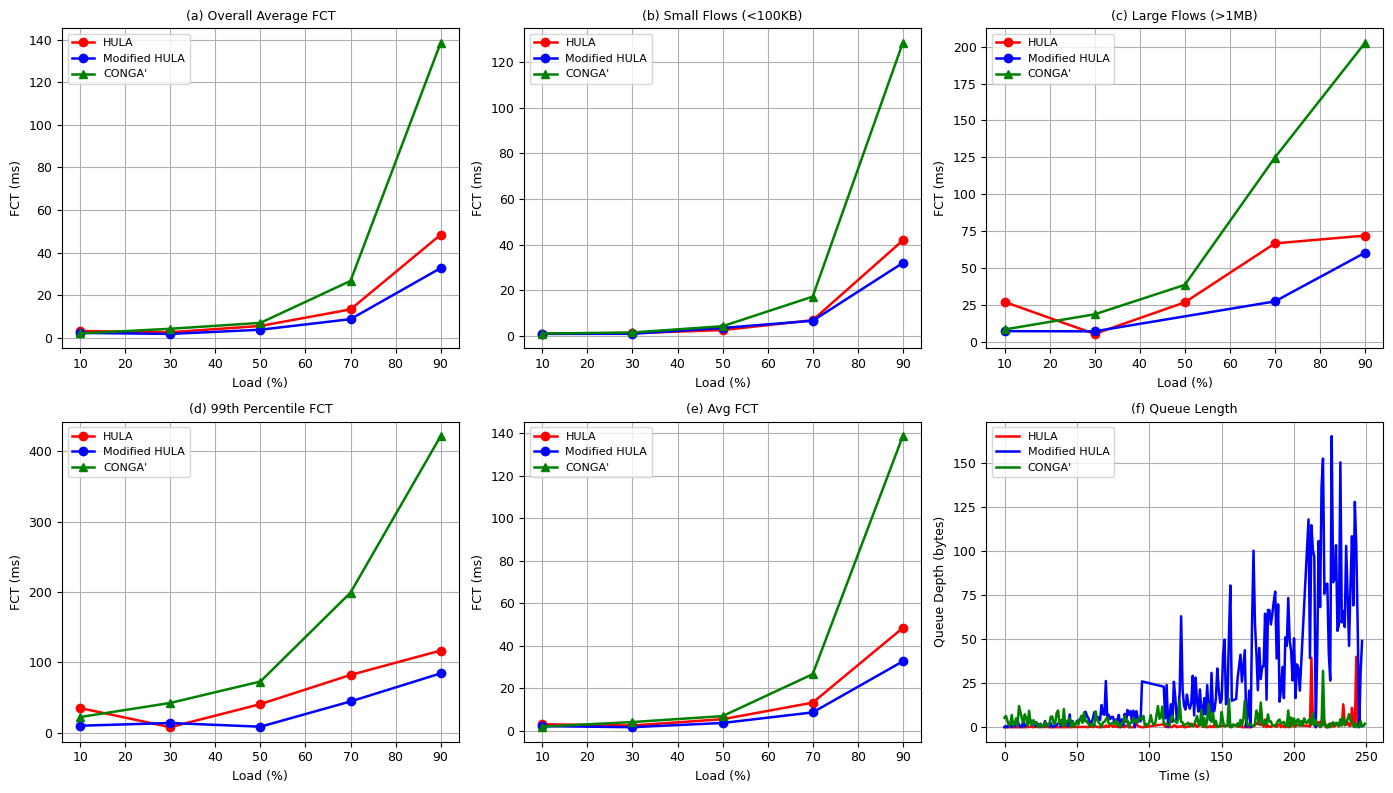

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
orig  = pd.read_csv("Original_Hula.csv")
mod   = pd.read_csv("Modified_Hula.csv")
conga = pd.read_csv("conga.csv")

# Drop NaN rows in conga (OTHER-protocol rows have no fct/size)
conga = conga.dropna(subset=['flow_size_bytes', 'fct_ms'])

# ---------- Flow Categories ----------
small_threshold = 100 * 1024        # <100KB
large_threshold = 1 * 1024 * 1024   # >1MB

def classify_flow(size):
    if size < small_threshold:
        return "small"
    elif size > large_threshold:
        return "large"
    else:
        return "medium"

orig['flow_cat']  = orig['flow_size_bytes'].apply(classify_flow)
mod['flow_cat']   = mod['flow_size_bytes'].apply(classify_flow)
conga['flow_cat'] = conga['flow_size_bytes'].apply(classify_flow)

# ---------- Aggregations ----------
# (a) Overall Avg FCT
orig_overall  = orig.groupby('load_percent')['fct_ms'].mean()
mod_overall   = mod.groupby('load_percent')['fct_ms'].mean()
conga_overall = conga.groupby('load_percent')['fct_ms'].mean()

# (b) Small flows
orig_small  = orig[orig['flow_cat']   == 'small'].groupby('load_percent')['fct_ms'].mean()
mod_small   = mod[mod['flow_cat']     == 'small'].groupby('load_percent')['fct_ms'].mean()
conga_small = conga[conga['flow_cat'] == 'small'].groupby('load_percent')['fct_ms'].mean()

# (c) Large flows
orig_large  = orig[orig['flow_cat']   == 'large'].groupby('load_percent')['fct_ms'].mean()
mod_large   = mod[mod['flow_cat']     == 'large'].groupby('load_percent')['fct_ms'].mean()
conga_large = conga[conga['flow_cat'] == 'large'].groupby('load_percent')['fct_ms'].mean()

# (d) 99th percentile FCT
orig_p99  = orig.groupby('load_percent')['fct_ms'].quantile(0.99)
mod_p99   = mod.groupby('load_percent')['fct_ms'].quantile(0.99)
conga_p99 = conga.groupby('load_percent')['fct_ms'].quantile(0.99)

# (f) Queue depth over time
orig_q  = orig.groupby('time_sec')['queue_depth_bytes'].mean()
mod_q   = mod.groupby('time_sec')['queue_depth_bytes'].mean()
conga_q = conga.groupby('time_sec')['queue_depth_bytes'].mean()

# ---------- Plot ----------
fig, axs = plt.subplots(2, 3, figsize=(14, 8))

# (a) Overall
axs[0, 0].plot(orig_overall.index,  orig_overall.values,  'r-o', label='HULA')
axs[0, 0].plot(mod_overall.index,   mod_overall.values,   'b-o', label='Modified HULA')
axs[0, 0].plot(conga_overall.index, conga_overall.values, 'g-^', label="CONGA'")
axs[0, 0].set_title("(a) Overall Average FCT")
axs[0, 0].set_xlabel("Load (%)"); axs[0, 0].set_ylabel("FCT (ms)"); axs[0, 0].grid()

# (b) Small flows
axs[0, 1].plot(orig_small.index,  orig_small.values,  'r-o', label='HULA')
axs[0, 1].plot(mod_small.index,   mod_small.values,   'b-o', label='Modified HULA')
axs[0, 1].plot(conga_small.index, conga_small.values, 'g-^', label="CONGA'")
axs[0, 1].set_title("(b) Small Flows (<100KB)")
axs[0, 1].set_xlabel("Load (%)"); axs[0, 1].set_ylabel("FCT (ms)"); axs[0, 1].grid()

# (c) Large flows
axs[0, 2].plot(orig_large.index,  orig_large.values,  'r-o', label='HULA')
axs[0, 2].plot(mod_large.index,   mod_large.values,   'b-o', label='Modified HULA')
axs[0, 2].plot(conga_large.index, conga_large.values, 'g-^', label="CONGA'")
axs[0, 2].set_title("(c) Large Flows (>1MB)")
axs[0, 2].set_xlabel("Load (%)"); axs[0, 2].set_ylabel("FCT (ms)"); axs[0, 2].grid()

# (d) 99th percentile
axs[1, 0].plot(orig_p99.index,  orig_p99.values,  'r-o', label='HULA')
axs[1, 0].plot(mod_p99.index,   mod_p99.values,   'b-o', label='Modified HULA')
axs[1, 0].plot(conga_p99.index, conga_p99.values, 'g-^', label="CONGA'")
axs[1, 0].set_title("(d) 99th Percentile FCT")
axs[1, 0].set_xlabel("Load (%)"); axs[1, 0].set_ylabel("FCT (ms)"); axs[1, 0].grid()

# (e) Overall FCT (repeat / medium flows)
axs[1, 1].plot(orig_overall.index,  orig_overall.values,  'r-o', label='HULA')
axs[1, 1].plot(mod_overall.index,   mod_overall.values,   'b-o', label='Modified HULA')
axs[1, 1].plot(conga_overall.index, conga_overall.values, 'g-^', label="CONGA'")
axs[1, 1].set_title("(e) Avg FCT")
axs[1, 1].set_xlabel("Load (%)"); axs[1, 1].set_ylabel("FCT (ms)"); axs[1, 1].grid()

# (f) Queue depth over time
axs[1, 2].plot(orig_q.index,  orig_q.values,  'r-', label='HULA')
axs[1, 2].plot(mod_q.index,   mod_q.values,   'b-', label='Modified HULA')
axs[1, 2].plot(conga_q.index, conga_q.values, 'g-', label="CONGA'")
axs[1, 2].set_title("(f) Queue Length")
axs[1, 2].set_xlabel("Time (s)"); axs[1, 2].set_ylabel("Queue Depth (bytes)"); axs[1, 2].grid()

# Legends
for ax in axs.flat:
    ax.legend()

plt.tight_layout()
plt.show()